In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import pandas as pd

# Load dataset using exact path
df = pd.read_csv(r'C:\Users\irfan\CodeAlpha_Projects\Unemployment_Rate_upto_11_2020.csv')

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [3]:
import os

filename = 'Unemployment_Rate_upto_11_2020.csv'
search_dir = r'C:\Users\irfan'
found = False

for root, dirs, files in os.walk(search_dir):
    if filename in files:
        full_path = os.path.join(root, filename)
        print("FILE FOUND!")
        print(f"\nCopy and paste this exact line into Cell 2:\n")
        print(f"df = pd.read_csv(r'{full_path}')")
        found = True
        break

if not found:
    print("File not found on system. Please download 'Unemployment_Rate_upto_11_2020.csv' again.")

FILE FOUND!

Copy and paste this exact line into Cell 2:

df = pd.read_csv(r'C:\Users\irfan\CodeAlpha_Projects\Unemployment_Rate_upto_11_2020.csv')


In [4]:
# Strip extra spaces from existing column headers
df.columns = df.columns.str.strip()

# Map original column keywords to clean names safely
df = df.rename(columns={
    'Region': 'Region',
    'Date': 'Date',
    'Frequency': 'Frequency',
    'Estimated Unemployment Rate (%)': 'Estimated Unemployment Rate (%)',
    'Estimated Employed': 'Estimated Employed',
    'Estimated Labour Participation Rate (%)': 'Estimated Labour Participation Rate (%)',
    'Area': 'Area',
    'longitude': 'Longitude',
    'latitude': 'Latitude'
})

print("Cleaned Column Names:")
print(df.columns.tolist())

Cleaned Column Names:
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'Longitude', 'Latitude']


In [5]:
# Inspect structure, data types, and null values
print("Dataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# Clean missing values if any exist
df = df.dropna()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   267 non-null    str    
 1   Date                                     267 non-null    str    
 2   Frequency                                267 non-null    str    
 3   Estimated Unemployment Rate (%)          267 non-null    float64
 4   Estimated Employed                       267 non-null    int64  
 5   Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                 267 non-null    str    
 7   Longitude                                267 non-null    float64
 8   Latitude                                 267 non-null    float64
dtypes: float64(4), int64(1), str(4)
memory usage: 18.9 KB
None

Missing Values:
Region                                    

In [6]:
# Convert Date to datetime object
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Extract temporal features for seasonal pattern analysis
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()

print("Preprocessing complete! Dataset shape:", df.shape)

Preprocessing complete! Dataset shape: (267, 11)


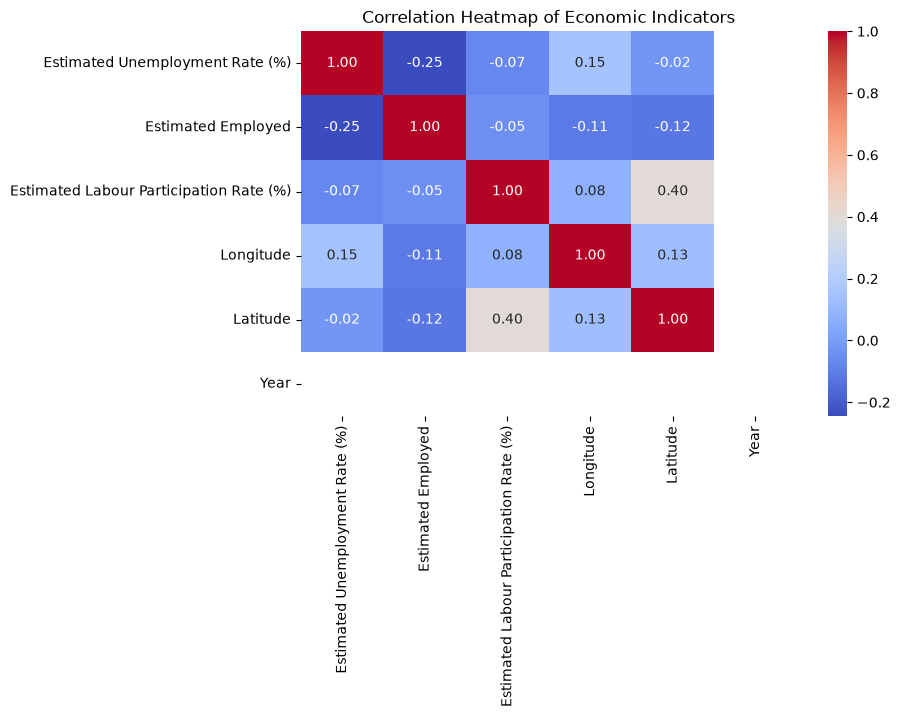

In [7]:
# Heatmap of numerical indicators
plt.figure(figsize=(8, 5))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Economic Indicators')
plt.savefig('unemployment_correlation.png', bbox_inches='tight')
plt.show()

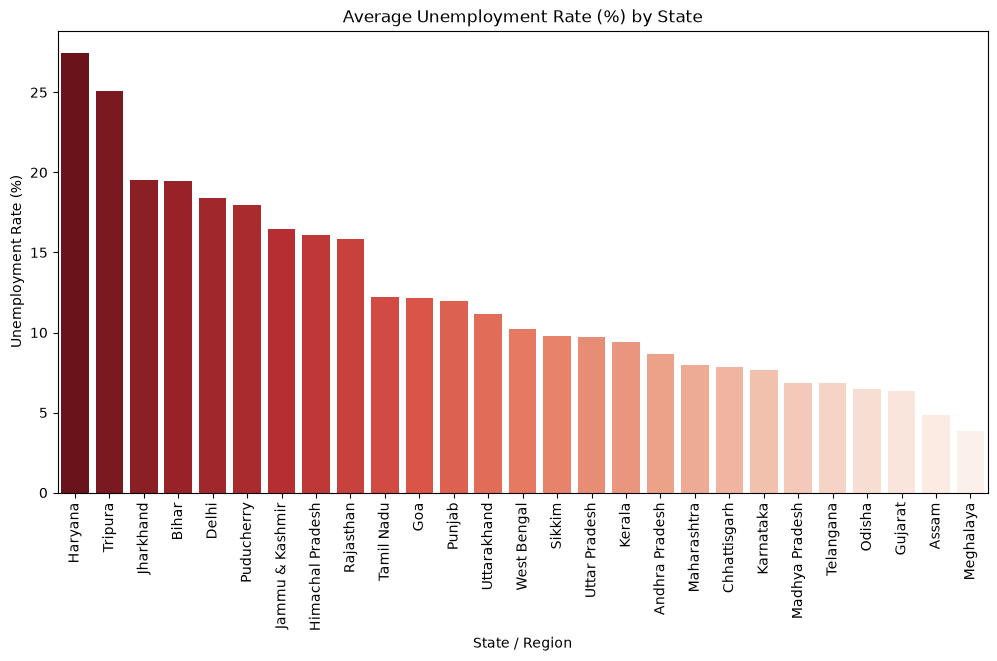

In [8]:
# State-wise average unemployment rate
plt.figure(figsize=(12, 6))
state_unemp = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

sns.barplot(x=state_unemp.index, y=state_unemp.values, hue=state_unemp.index, palette='Reds_r', legend=False)
plt.xticks(rotation=90)
plt.title('Average Unemployment Rate (%) by State')
plt.xlabel('State / Region')
plt.ylabel('Unemployment Rate (%)')
plt.savefig('unemployment_by_state.png', bbox_inches='tight')
plt.show()

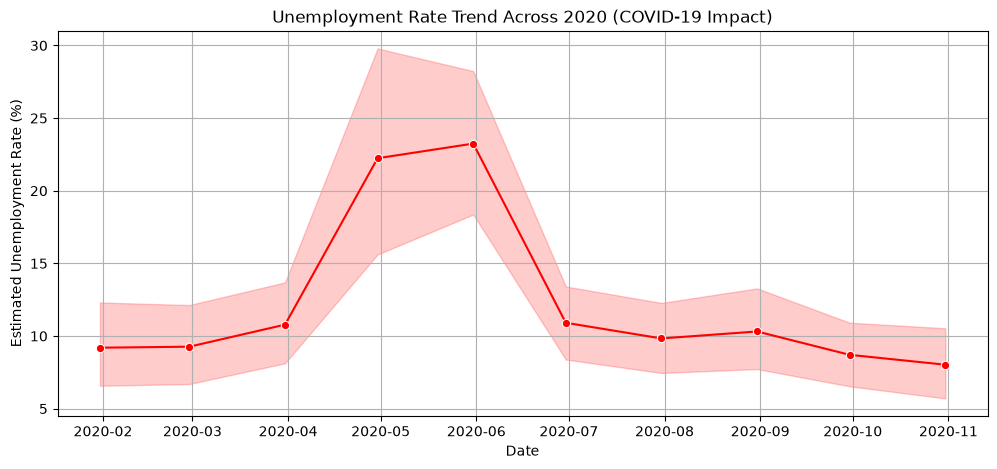

In [9]:
# Line plot tracking changes over time (2020 Lockdown Impact)
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)', color='red', marker='o')
plt.title('Unemployment Rate Trend Across 2020 (COVID-19 Impact)')
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.grid(True)
plt.savefig('unemployment_trend.png', bbox_inches='tight')
plt.show()

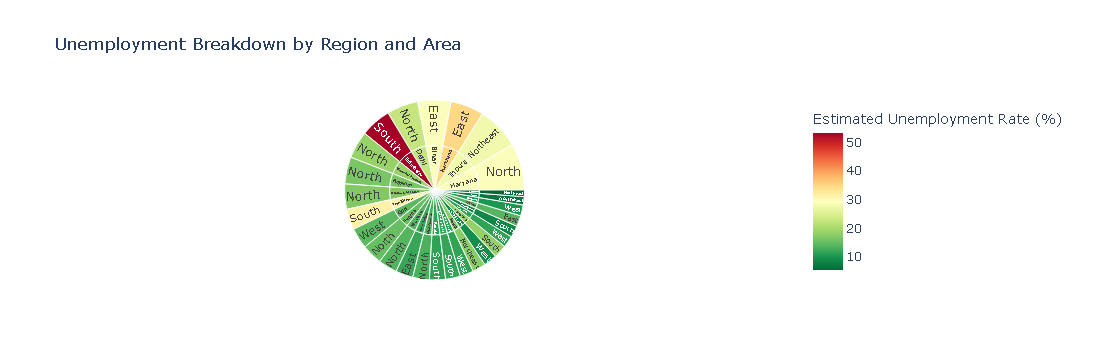

In [10]:
import plotly.express as px

# Use existing regional hierarchy columns
fig = px.sunburst(
    df, 
    path=['Region', 'Region.1'], 
    values='Estimated Unemployment Rate (%)',
    color='Estimated Unemployment Rate (%)', 
    color_continuous_scale='RdYlGn_r',
    title='Unemployment Breakdown by Region and Area'
)

fig.show()

In [11]:
highest_state = state_unemp.idxmax()
highest_val = state_unemp.max()
lowest_state = state_unemp.idxmin()
lowest_val = state_unemp.min()

print("--- KEY FINDINGS ---")
print(f"1. Highest Average Unemployment State: {highest_state} ({highest_val:.2f}%)")
print(f"2. Lowest Average Unemployment State: {lowest_state} ({lowest_val:.2f}%)")
print(f"3. Overall Average Unemployment Rate: {df['Estimated Unemployment Rate (%)'].mean():.2f}%")

--- KEY FINDINGS ---
1. Highest Average Unemployment State: Haryana (27.48%)
2. Lowest Average Unemployment State: Meghalaya (3.87%)
3. Overall Average Unemployment Rate: 12.24%
